# Titanic Machine Learning

Import all the necessary python libraries.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Start by reading in the train data (train.csv) using pandas read_csv method. Head() allows us to view the first N rows.

In [9]:
testdf = pd.read_csv("train.csv")
print("Data shape:", testdf.shape)
testdf.head(10)

Data shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


Here is what all the columns represent.

| Variable | Definition | Key |
| -------- | --------- | ---- |
| survived | Survival | 0 = No, 1 = Yes | 
| pclass | Ticket class | 1 = 1st, 2 = 2nd, 3 = 3rd |
| sex |	Sex	| |
| Age |	Age in years | |
| sibsp | # of siblings / spouses aboard the Titanic | |
| parch | # of parents / children aboard the Titanic | |
| ticket | Ticket number | |
| fare | Passenger fare | | 	
| cabin	| Cabin number | |
| embarked | Port of Embarkation | C = Cherbourg, Q = Queenstown, S = Southampton |

## Dataset Overview

To understand our dataset, we can use several of pandas' built-in methods. First, __df.info()__ allows us to get information on each of the columns.

In [14]:
testdf.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


Meanwhile, __df.describe()__ gives us a statistical understanding of each column (mean, median, etc.) for numeric data types. It ignores null values by default.

In [15]:
testdf.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


If we pass in include=['O'], or in other words, we call __df.describe(include=['O', 'str'])__, then it will generate a summary specifically for object (string/text) and categorical columns.

In [17]:
testdf.describe(include=['O', 'str'])

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


Lastly, it is useful for us to obtain a list of all the column names. The attribute for this is __df.columns__

In [18]:
testdf.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

## Missing Value Analysis

We can use our results from .info() to perform an analysis on the number of missing values for each column and row. To count the number of non-nan values in a specific pandas df column, we use __df['column_name'].count()__.

In [21]:
# counting number of non-NaN in each column
for column in testdf.columns:
    cnt = testdf[column].count()
    print(column + ": " + str(cnt))

PassengerId: 891
Survived: 891
Pclass: 891
Name: 891
Sex: 891
Age: 714
SibSp: 891
Parch: 891
Ticket: 891
Fare: 891
Cabin: 204
Embarked: 889


The __df.isnull()__ method is also useful as it returns a boolean mask identifying missing data. Everything is turned into true or false based on if NaN.

In [22]:
testdf.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


__df.sum()__ returns the sum over a requested axis (defaults to over rows so that you obtain column sums). 

In [28]:
cntdf = testdf.isnull().sum()
cntdf

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Series Detour

When using .sum() over all the columns, it produces a ***series***, a one-dimensional key-value list consisting of an index (the customizable axis labels for the data) and the values. When you create a new dataframe, it uses those indices to label the rows of the dataframe (everything is aligned based on those indices). The following example demonstrates alignment by indices.

In [29]:
s1 = pd.Series([10, 20, 30], index=["A", "B", "C"])
s2 = pd.Series([1, 2, 3], index=["B", "C", "D"])

df = pd.DataFrame({
    "count": s1,
    "percent": s2
})

df

,count,percent
A,10.0,NaN
B,20.0,1.0
C,30.0,2.0
D,NaN,3.0


## Back to Missing Value Analysis

Now, we can create a dataframe that stores the columns with missing values and the percentage of missing values.

In [34]:
missingdf = pd.DataFrame({
    "Missing Count": cntdf, #column 1 is just counts
    "Missing %": ((cntdf / testdf.shape[0]) * 100).round(3) # column 2 is percentage
})

# remove all columns with no missing values using boolean selection
missingdf = missingdf[missingdf["Missing Count"] > 0].sort_values("Missing %", ascending=False)
print("Columns with missing values: ")
missingdf

Columns with missing values: 


,Missing Count,Missing %
Cabin,687,77.104
Age,177,19.865
Embarked,2,0.224


Now, we can display the results via matplotlib. Specifically, we can use the __.subplots()__ method along with __fig__ and __ax__. The subplots method allows us to place multiple plots in one figure. The inner parameters are as follows: rows, columns, plot index. 

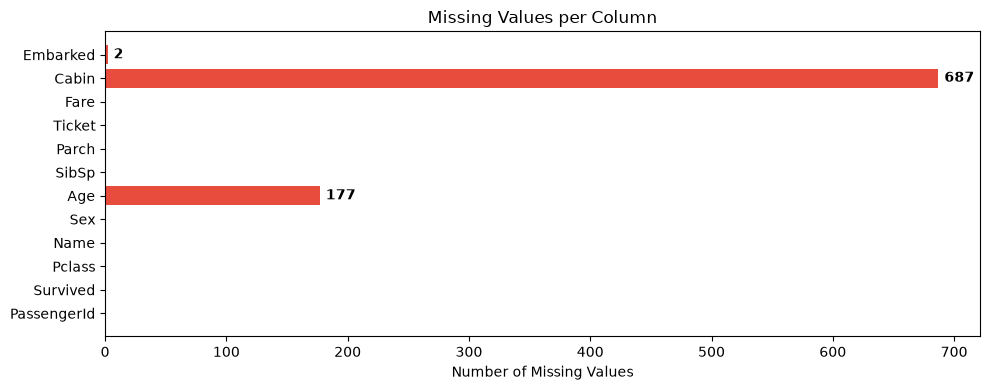

In [44]:
fig, ax = plt.subplots(figsize=(10, 4))
colors = ["#e74c3c" if testdf[col].isnull().any() else "#2ecc71" for col in testdf.columns]
ax.barh(testdf.columns, testdf.isnull().sum(), color=colors)
ax.set_xlabel("Number of Missing Values")
ax.set_title("Missing Values per Column")

for i, v in enumerate(testdf.isnull().sum()):
    if (v > 0):
        ax.text(v + 5, i, str(v), va="center", fontweight="bold")
plt.tight_layout()
plt.show()

## Analyzing the Target Variable (Survival)

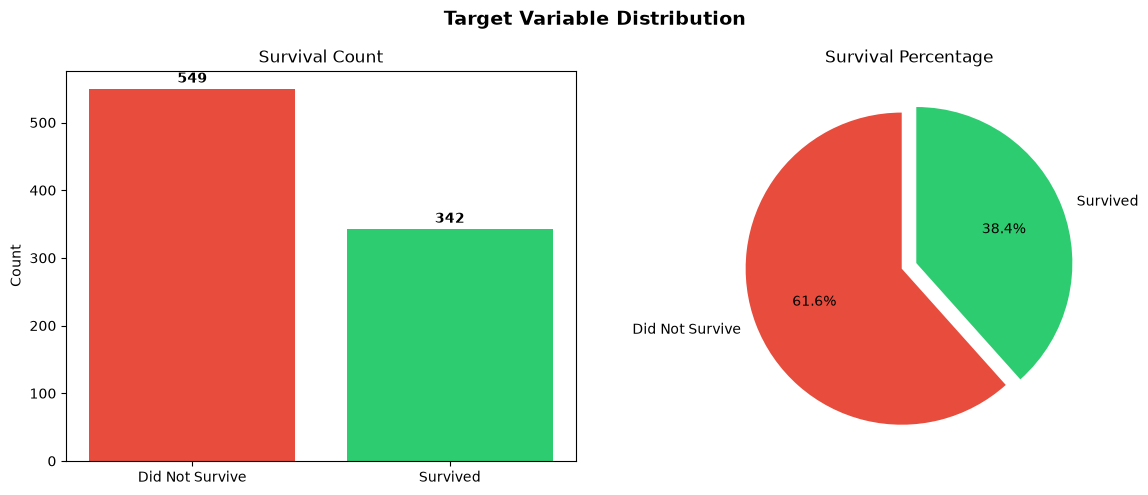

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

survive_counts = testdf["Survived"].value_counts() # returns a dataframe with the counts of unique values
axes[0].bar(["Did Not Survive", "Survived"], survive_counts.values, color=["#e74c3c", "#2ecc71"])
axes[0].set_title("Survival Count")
axes[0].set_ylabel("Count")

for i, v in enumerate(survive_counts.values):
    axes[0].text(i, v + 10, str(v), ha="center", fontweight="bold")

axes[1].pie(survive_counts.values, labels=["Did Not Survive", "Survived"], autopct="%1.1f%%", colors=["#e74c3c", "#2ecc71"], 
            startangle=90, explode=(0.05, 0.05))
axes[1].set_title("Survival Percentage")

plt.suptitle("Target Variable Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Univariate Analysis - Numerical Features

In [ ]:
fig, axes = plt.subplots()